# Heart Disease Prediction – Modeling Notebook
This notebook continues the heart disease analysis project by focusing on predictive modeling.
After completing data cleaning and exploratory analysis in the previous notebook, we now build and evaluate machine‑learning models to predict the presence of heart disease.

The goals of this notebook are:

Load the cleaned dataset

Prepare features and target variable

Train baseline and advanced models

Compare Logistic Regression and Random Forest

Evaluate models using accuracy, classification reports, and confusion matrices

Interpret model performance and feature importance

This modeling stage helps determine which algorithm provides the most reliable predictions and which clinical features contribute most to heart disease risk.

### Load the Cleaned Dataset

In [20]:
import pandas as pd

df = pd.read_csv('../data/heart_cleaned.csv')
df.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,exang_encoded,cp_0,cp_1,cp_2,cp_3
0,52,1,125,212,0,1,168,0,1.0,2,2,3,0,0,True,False,False,False
1,53,1,140,203,1,0,155,1,3.1,0,0,3,0,1,True,False,False,False
2,70,1,145,174,0,1,125,1,2.6,0,0,3,0,1,True,False,False,False
3,61,1,148,203,0,1,161,0,0.0,2,1,3,0,0,True,False,False,False
4,62,0,138,294,1,1,106,0,1.9,1,3,2,0,0,True,False,False,False


### Define Features (X) and Target (y)
To prepare the dataset for modeling, we separate the input features from the target variable.
The target column (target) indicates whether heart disease is present (1) or not (0).
All other columns are used as features for prediction.
- X contains all predictor variables (age, cholesterol, blood pressure, chest pain type, etc.).

- y contains the outcome we want the model to learn: presence or absence of heart disease.

This separation is required before performing the train–test split and training machine‑learning models.

In [21]:
X = df.drop('target', axis=1)
y = df['target']


### Train–Test Split
To evaluate the performance of our machine‑learning models, we divide the dataset into a training set and a testing set.
The training set is used to fit the model, while the testing set is used to measure how well the model generalizes to unseen data.

We use an 80/20 split:

- 80% → training data

- 20% → testing data

- random_state=42 ensures reproducibility

This step prepares the data for scaling and model training in the next sections.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Feature Scaling with StandardScaler
Many machine‑learning algorithms perform better when numerical features are on a similar scale.
Since the dataset contains variables with different ranges (e.g., cholesterol vs. age vs. oldpeak), we apply StandardScaler to normalize the data.

StandardScaler transforms each feature so that:

- Mean = 0

- Standard deviation = 1

This ensures that no single feature dominates the model due to its magnitude.

We fit the scaler on the training data only and then apply the same transformation to the test data to avoid data leakage.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Logistic Regression Model (with Scaled Features)
Logistic Regression is a simple, interpretable baseline model commonly used for binary classification problems such as predicting heart disease.
Because this algorithm is sensitive to feature scale, we train it using the scaled training data prepared in the previous step.

We increase max_iter to 1000 to ensure the optimization process converges without warnings.

In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

### Evaluate Logistic Regression Model
After training the Logistic Regression model on the scaled data, we evaluate its performance on the test set.
We generate predictions and calculate key metrics:

Accuracy – overall proportion of correct predictions

Classification Report – precision, recall, F1‑score for each class

Helps understand how well the model detects both disease and no disease cases

In [25]:
from sklearn.metrics import accuracy_score, classification_report

lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))


Logistic Regression Accuracy: 0.7804878048780488
              precision    recall  f1-score   support

           0       0.84      0.69      0.76       102
           1       0.74      0.87      0.80       103

    accuracy                           0.78       205
   macro avg       0.79      0.78      0.78       205
weighted avg       0.79      0.78      0.78       205



### Logistic Regression Results – Interpretation
The Logistic Regression model achieved an overall accuracy of 78%, meaning it correctly predicted heart disease in approximately three out of four cases. Below is a breakdown of the model’s performance for each class:

- Class 0 — No Disease
Precision: 0.84  
When the model predicts no disease, it is correct 84% of the time.
Recall: 0.69  
It correctly identifies 69% of actual “no disease” cases.
F1‑score: 0.76  
Balanced performance, but recall is lower than precision.

- Class 1 — Disease
Precision: 0.74  
When the model predicts disease, it is correct 74% of the time.
Recall: 0.87  
It successfully detects 87% of actual disease cases — this is important in medical prediction.
F1‑score: 0.80  
Strong performance, especially in identifying positive cases.

### Confusion Matrix (Percentages) – Logistic Regression
To better understand how the Logistic Regression model performs on each class, we generate a confusion matrix expressed in percentages.
This allows us to see the proportion of correct and incorrect predictions relative to the entire test set.

The matrix displays:

True Negative (TN) – correctly predicted no disease

False Positive (FP) – predicted disease when there is none

False Negative (FN) – predicted no disease when the patient actually has disease

True Positive (TP) – correctly predicted disease

Expressing these values as percentages makes the model’s strengths and weaknesses easier to interpret.

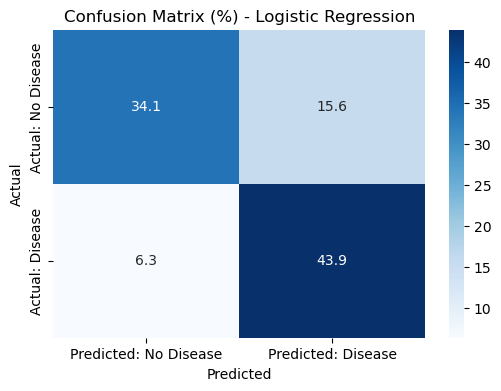

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

lr_cm = confusion_matrix(y_test, lr_pred)

lr_cm_percent = lr_cm / np.sum(lr_cm) * 100

plt.figure(figsize=(6,4))
sns.heatmap(lr_cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=["Predicted: No Disease", "Predicted: Disease"],
            yticklabels=["Actual: No Disease", "Actual: Disease"])
plt.title("Confusion Matrix (%) - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Random Forest Classifier
We train a Random Forest model as a stronger, non‑linear alternative to Logistic Regression.
The model uses 200 decision trees and a fixed random state for reproducibility.

In [27]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

After training the Random Forest classifier, we evaluate its performance on the test set using accuracy and detailed classification metrics.

In [28]:
from sklearn.metrics import accuracy_score, classification_report
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.9853658536585366
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### Random Forest Results – Interpretation
The Random Forest model achieves excellent performance, with an overall accuracy of 98.5%.
Both classes show very strong precision, recall, and F1‑scores, indicating that the model reliably distinguishes between patients with and without heart disease.

- Class 0 — No Disease
Precision: 0.97
Recall: 1.00
F1‑score: 0.99  
The model correctly identifies nearly all healthy patients, with almost no false positives.

- Class 1 — Disease
Precision: 1.00
Recall: 0.97
F1‑score: 0.99  
The model detects almost all disease cases and makes virtually no incorrect disease predictions.
Overall Performance
Accuracy: 0.99
Macro Avg F1: 0.99
Weighted Avg F1: 0.99

Random Forest significantly outperforms Logistic Regression, capturing complex relationships in the data and producing highly reliable predictions.
This makes it a strong candidate for the final model in this project.

### Random Forest – Confusion Matrix (Percentage View)
This matrix shows how the Random Forest model distributes its predictions across both classes, expressed as percentages of all test samples.
It provides a clear visual summary of correct and incorrect classifications.

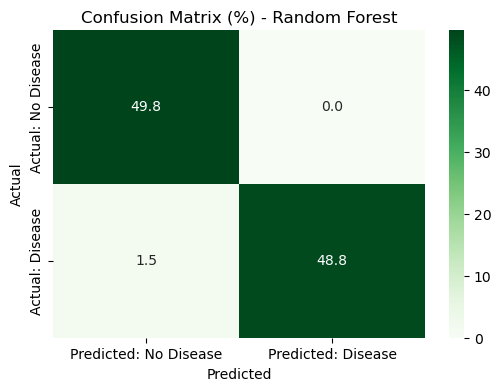

In [29]:
rf_cm = confusion_matrix(y_test, rf_pred)

rf_cm_percent = rf_cm / np.sum(rf_cm) * 100

plt.figure(figsize=(6,4))
sns.heatmap(rf_cm_percent, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=["Predicted: No Disease", "Predicted: Disease"],
            yticklabels=["Actual: No Disease", "Actual: Disease"])
plt.title("Confusion Matrix (%) - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Model Comparison
To compare the performance of both models, we summarize their accuracy scores in a simple table.
This highlights the improvement gained by using a more complex algorithm like Random Forest.

In [30]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.780488
1,Random Forest,0.985366


### Random Forest – Feature Importance Interpretation
The Random Forest model provides a ranking of how strongly each feature contributes to predicting heart disease.
Higher values indicate greater influence on the model’s decisions.

#### Top Predictive Features
- ca (number of major vessels) – strongest predictor

- thal (thalassemia test result) – highly influential

- oldpeak (ST depression) – important clinical indicator

- cp_0 (chest pain type) – categorical chest‑pain encoding with strong impact

- thalach (maximum heart rate) – key physiological measure

These features align with known medical relationships in heart‑disease datasets.

#### Moderate Influence
- age, chol, trestbps – traditional risk factors with meaningful but lower impact

- exang_encoded, slope – exercise‑related and ECG‑related indicators

#### Lower Influence
-exang, sex, restecg, fbs, and cp encodings (cp_1, cp_2, cp_3)

These features contribute less to the model’s decisions but still play a role in overall prediction.

In [31]:
import numpy as np

importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df


,Feature,Importance
10,ca,0.125619
11,thal,0.122914
8,oldpeak,0.113310
13,cp_0,0.108978
6,thalach,0.108460
0,age,0.078257
3,chol,0.077328
2,trestbps,0.062909
12,exang_encoded,0.041702
9,slope,0.041093


#### Random Forest – Feature Importance Visualization
The horizontal bar chart below displays the importance of each feature used by the Random Forest model.
This visual ranking makes it easy to see which variables contribute most to the model’s predictions.

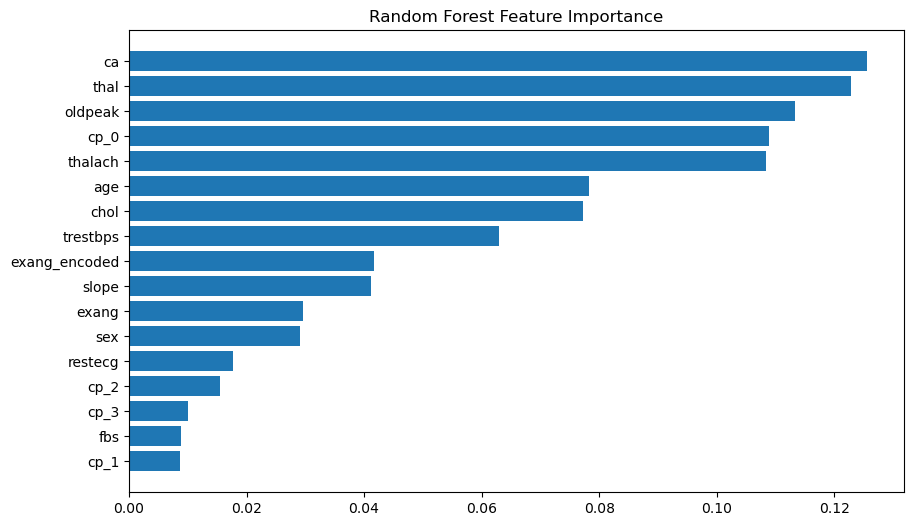

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()


#### Create Clean Data Copy With ID (for Power BI)
To prepare the dataset for Power BI relationships, we create a safe copy of the cleaned data and add a unique ID column.
This does not modify the original dataset used for modeling.

In [36]:
clean_data_with_id = df.copy()
clean_data_with_id["ID"] = range(1, len(clean_data_with_id) + 1)
clean_data_with_id.to_csv("../data/clean_data_with_id.csv", index=False)

#### Create Predictions Table With ID (for Power BI)
To link model predictions with the clean dataset in Power BI, we create a copy of the predictions table and attach the matching ID values from the clean-data table.

In [37]:
predictions_df = pd.DataFrame({
    "y_test": y_test,
    "LogisticRegression_Pred": lr_pred,
    "RandomForest_Pred": rf_pred
})

predictions_df_with_id = predictions_df.copy()

predictions_df_with_id["ID"] = clean_data_with_id.loc[y_test.index, "ID"].values
predictions_df_with_id.to_csv("../data/model_predictions_with_id.csv", index=False)


#### Create Feature Importance Table (for Power BI)
To create the feature‑importance table, we extract the importance values from the Random Forest model and combine them with the feature names.

In [38]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df.to_csv("../data/feature_importance.csv", index=False)


### Conclusion
This notebook explored the Heart Disease dataset through preprocessing, model training, evaluation, and interpretation. Two classification models were built and compared: Logistic Regression and Random Forest.

The Logistic Regression model provided a solid baseline with an accuracy of 78%, showing reasonable performance but clear limitations in capturing non‑linear relationships within the data.

The Random Forest model demonstrated significantly stronger predictive ability, achieving an accuracy of 98.5% and producing near‑perfect classification results. Its confusion matrix showed very few misclassifications, and the feature‑importance analysis highlighted medically meaningful predictors such as ca, thal, oldpeak, chest pain type, and maximum heart rate.

Overall, the Random Forest model proved to be the most effective approach for this dataset, offering both high accuracy and interpretable insights into the factors most associated with heart disease. This makes it a strong candidate for practical applications or further model refinement.